In [88]:
from google.colab import files
uploaded = files.upload()


Saving Azure_demand_forecasting_Dataset.csv to Azure_demand_forecasting_Dataset (1).csv


In [ ]:
import pandas as pd

df = pd.read_csv("Azure_demand_forecasting_Dataset.csv")
df.head()


In [ ]:
df.info()


In [ ]:
df.isnull().sum()


In [ ]:
print("Duplicates before:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Duplicates after:", df.duplicated().sum())


In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'], format='%d-%m-%Y')
df.info()


In [ ]:
print("Negative demand:", (df['demand_units'] < 0).sum())
print("Availability > 100:", (df['service_availability'] > 100).sum())


In [ ]:
df.to_csv("azure_demand_cleaned.csv", index=False)


In [ ]:
from google.colab import files
files.download("azure_demand_cleaned.csv")


In [ ]:
df['year'] = df['timestamp'].dt.year
df['month'] = df['timestamp'].dt.month
df['quarter'] = df['timestamp'].dt.quarter


In [ ]:
df.to_csv("azure_demand_final_milestone1.csv", index=False)


In [ ]:
from google.colab import files
files.download("azure_demand_final_milestone1.csv")


In [ ]:
### MILE STONE -2

In [ ]:
#Azure Demand Forecasting – Milestone 2
#model without lag features
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# loading the dataset
df = pd.read_csv("azure_demand_cleaned.csv")
df.head()

In [ ]:
#converting time stamp
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['year'] = df['timestamp'].dt.year
df['month'] = df['timestamp'].dt.month
df['quarter'] = df['timestamp'].dt.quarter
df['day_of_week'] = df['timestamp'].dt.dayofweek

In [ ]:
#demand trend overtime
plt.figure(figsize=(12,5))
plt.plot(df['timestamp'], df['demand_units'])
plt.title("Demand Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Demand Units")
plt.show()

In [ ]:
# Monthly demand aggregation
monthly_demand = df.groupby('month')['demand_units'].mean()

plt.figure(figsize=(8,5))
monthly_demand.plot(kind='bar')
plt.title("Average Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Demand")
plt.show()

In [ ]:
# Correlation Analysis
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
### Correlation Insights

#- Demand units show strong positive correlation with capacity allocation (0.98).
#- Month and quarter are highly correlated (0.97), as quarter is derived from month.
#- Economic indicators show moderate influence on demand.
#- No extreme negative correlations observed.

In [ ]:
#preparing datat for model
X = df[['year', 'month', 'quarter', 'day_of_week',
        'gdp_growth_rate', 'inflation_rate',
        'it_sector_growth_index', 'capacity_allocated']]

y = df['demand_units']

In [ ]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
#Train Random Forest
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

In [ ]:
#conclusion

# The Random Forest regression model achieved strong predictive performance with an R² score of 0.95, indicating that 95% of the variance in Azure demand is explained by the selected features.

# The low MAE and RMSE values show that prediction errors are minimal. Capacity allocation shows strong correlation with demand, while economic indicators provide additional predictive strength.

# This model can assist in effective Azure capacity planning and demand forecasting.

In [ ]:
#model with lag features
# Create lag features (previous 7 days demand)

for i in range(1, 8):
    df[f'lag_{i}'] = df['demand_units'].shift(i)

df.head()

In [ ]:
df.dropna(inplace=True)

In [ ]:
X = df[['year', 'month', 'quarter', 'day_of_week',
        'gdp_growth_rate', 'inflation_rate',
        'it_sector_growth_index', 'capacity_allocated',
        'lag_1', 'lag_2', 'lag_3', 'lag_4',
        'lag_5', 'lag_6', 'lag_7']]

y = df['demand_units']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

In [ ]:
### Model Improvement Using Lag Features

# After introducing lag features (previous 7 days demand), the model performance improved from R² = 0.95 to R² = 0.96.

# This indicates that historical demand plays an important role in predicting future Azure demand. Lag features helped the model capture temporal dependencies and improved forecasting accuracy.

In [ ]:
## 8. Rolling Mean Feature Engineering
# 7-day rolling mean
df['rolling_7'] = df['demand_units'].rolling(window=7).mean()

df.head()

In [ ]:
#Drop NaN Values
df.dropna(inplace=True)


In [ ]:
#Updating Feature Set
X = df[['year', 'month', 'quarter', 'day_of_week',
        'gdp_growth_rate', 'inflation_rate',
        'it_sector_growth_index', 'capacity_allocated',
        'lag_1', 'lag_2', 'lag_3', 'lag_4',
        'lag_5', 'lag_6', 'lag_7',
        'rolling_7']]

y = df['demand_units']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

In [ ]:
### Rolling Mean Experiment

# A 7-day rolling mean feature was introduced to capture short-term trends. However, the model performance slightly decreased (R² reduced from 0.9618 to 0.9603).

# This indicates that lag features were sufficient to capture temporal dependencies, and rolling mean did not provide additional predictive benefit.

In [ ]:
df.info()
df.head()
df.isnull().sum()

MILE STONE-3

In [ ]:
import pandas as pd
import numpy as np

from statsmodels.tsa.arima.model import ARIMA

from xgboost import XGBRegressor

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error

In [ ]:
#Extract time components

df["year"] = df["timestamp"].dt.year
df["month"] = df["timestamp"].dt.month
df["day"] = df["timestamp"].dt.day

In [ ]:
# dropping org timestamp

df = df.drop("timestamp", axis=1)

In [ ]:
#define features and target

X = df.drop("demand_units", axis=1)
y = df["demand_units"]

In [ ]:
# train-test split

train_size = int(len(df) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [ ]:
# baseline ARIMA model

arima_model = ARIMA(y_train, order=(1,1,1))
arima_model_fit = arima_model.fit()

In [ ]:
#ARIMA forecast

arima_pred = arima_model_fit.forecast(steps=len(y_test))

In [ ]:
# Baseline XGBoost Model

# One-hot encode categorical features
X_train_encoded = pd.get_dummies(X_train, columns=['azure_region', 'service_type'], drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=['azure_region', 'service_type'], drop_first=True)

xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    objective="reg:squarederror"
)

xgb_model.fit(X_train_encoded, y_train)

In [ ]:
# XGBoost prediction

xgb_pred = xgb_model.predict(X_test_encoded)

In [ ]:
# Baseline Model evaluation

rmse_arima = np.sqrt(mean_squared_error(y_test, arima_pred))
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))

print("Baseline ARIMA RMSE:", rmse_arima)
print("Baseline XGBoost RMSE:", rmse_xgb)

In [ ]:
# ARIMA Hyperparameter Tuning

p = range(0,4)
d = range(0,2)
q = range(0,4)

best_score = float("inf")

best_order = None

In [ ]:
# Grid Search

for i in p:
    for j in d:
        for k in q:

            try:
                model = ARIMA(y_train, order=(i,j,k))
                model_fit = model.fit()

                pred = model_fit.forecast(steps=len(y_test))

                rmse = np.sqrt(mean_squared_error(y_test, pred))

                if rmse < best_score:
                    best_score = rmse
                    best_order = (i,j,k)

            except:
                continue

In [ ]:
# Train the Best ARIMA Model

best_arima_model = ARIMA(y_train, order=best_order).fit()

arima_tuned_pred = best_arima_model.forecast(steps=len(y_test))

In [ ]:
# XGBoost Hyperparameter Tuning

param_grid = {

    "n_estimators": [100,200,300],
    "max_depth": [3,5,7],
    "learning_rate": [0.01,0.1],
    "subsample": [0.8,1]

}

In [ ]:
# GridSearchCV

grid_search = GridSearchCV(
    estimator=XGBRegressor(objective="reg:squarederror", random_state=42),
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=3,
    verbose=1
)

grid_search.fit(X_train_encoded, y_train)

In [ ]:
# Best parameters from GridSearchCV
best_xgb_params = grid_search.best_params_
print("Best XGBoost parameters:", best_xgb_params)

In [ ]:
# Train XGBoost with best parameters
tuned_xgb_model = XGBRegressor(objective="reg:squarederror", random_state=42, **best_xgb_params)
tuned_xgb_model.fit(X_train_encoded, y_train)

In [ ]:
# Tuned XGBoost prediction
tuned_xgb_pred = tuned_xgb_model.predict(X_test_encoded)

In [ ]:
# Final Model Evaluation

rmse_arima_tuned = np.sqrt(mean_squared_error(y_test, arima_tuned_pred))
rmse_xgb_tuned = np.sqrt(mean_squared_error(y_test, tuned_xgb_pred))

print("Tuned ARIMA RMSE:", rmse_arima_tuned)
print("Tuned XGBoost RMSE:", rmse_xgb_tuned)

In [ ]:
# Visulization
import matplotlib.pyplot as plt
import numpy as np

# Taken few points for clean graph
actual_plot = y_test[:5].values
arima_plot = arima_pred[:5]
xgb_plot = xgb_pred[:5]

# Creating same x-axis
x = np.arange(len(actual_plot))

plt.figure(figsize=(8,5))

plt.plot(x, actual_plot, marker='o', label='Actual')
plt.plot(x, arima_plot, marker='o', label='ARIMA')
plt.plot(x, xgb_plot, marker='o', label='XGBoost')

plt.title("Demand Forecast Comparison")
plt.xlabel("Time Steps")
plt.ylabel("Demand Units")
plt.legend()

plt.show()

## Milestone 4: Forecast Integration & Capacity Planning

In [ ]:
import pandas as pd

# Start with the cleaned dataset to reconstruct df completely
df = pd.read_csv("azure_demand_cleaned.csv")

# Ensure timestamp is datetime (it should be from azure_demand_cleaned.csv, but re-confirm)
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Extract time components - year, month, quarter, day_of_week (as done before lag and rolling mean)
df['year'] = df['timestamp'].dt.year
df['month'] = df['timestamp'].dt.month
df['quarter'] = df['timestamp'].dt.quarter
df['day_of_week'] = df['timestamp'].dt.dayofweek

# Create lag features
for i in range(1, 8):
    df[f'lag_{i}'] = df['demand_units'].shift(i)

# Create rolling mean feature
df['rolling_7'] = df['demand_units'].rolling(window=7).mean()

# Drop rows with NaN values resulting from lag and rolling features
df.dropna(inplace=True)

# Add 'day' feature (this was added in Milestone 3 after lag/rolling features in the original pipeline)
df['day'] = df['timestamp'].dt.day

# Drop the original timestamp column
df = df.drop("timestamp", axis=1)

# Prepare features for prediction
X_predict = df.drop("demand_units", axis=1)
X_predict_encoded = pd.get_dummies(X_predict, columns=['azure_region', 'service_type'], drop_first=True)

# Make predictions using the tuned XGBoost model
# This assumes 'tuned_xgb_model' is defined and in scope from previous cell executions
df['forecast'] = tuned_xgb_model.predict(X_predict_encoded)

# Save predictions for dashboard use
df.to_csv('forecast_output.csv', index=False)

print("Forecast output file generated successfully!")

## Milestone 4: Forecast Integration & Capacity Planning

In this milestone, the trained model is integrated into a system to generate predictions.

Batch prediction is performed where the model processes input data and saves the predicted values into a CSV file.

This file can be used in visualization tools like Power BI or Tableau to create dashboards for demand analysis.

The system can be automated using schedulers to update predictions regularly.

Model performance is monitored using RMSE, and retraining can be done when accuracy decreases.

This demonstrates real-world usage of the forecasting model.

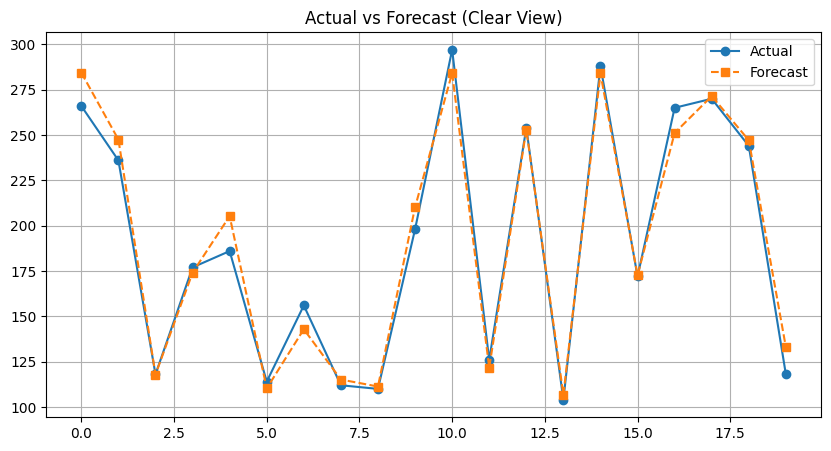

In [89]:
df_sample = df.iloc[:20]  # first 20 points

plt.figure(figsize=(10,5))

plt.plot(df_sample['demand_units'], 'o-', label='Actual')
plt.plot(df_sample['forecast'], 's--', label='Forecast')

plt.title("Actual vs Forecast (Clear View)")
plt.legend()
plt.grid(True)

plt.show()